In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import jax
jax.config.update('jax_default_device', 'cpu')
jax.config.update('jax_default_matmul_precision', 'highest')

In [2]:
import jax.numpy as jnp
import jax.random as jr
import jax.tree_util as jtu
import matplotlib.pyplot as plt
import seaborn as sns

from functools import partial
from jax import vmap
from scipy.linalg import orthogonal_procrustes, solve

from sppcax.distributions import MultivariateNormalInverseGamma as MVNIG, MultivariateNormal

from sppcax.models import BayesianDynamicFactorAnalysis as BDFA
from sppcax.models.dynamic_factor_analysis import (
    ParamsLGSSM, ParamsLGSSMInitial,
)
from sppcax.inference.utils import ParamsLGSSMVB
from dynamax.linear_gaussian_ssm import parallel_lgssm_smoother

# Testing PXL-EM for Dynamic Factor Analysis

This notebook tests the **Parameter-Expanded Likelihood EM (PXL-EM)** algorithm
applied to Bayesian Dynamic Factor Analysis (DFA).

Compared to static FA, the DFA PXL-EM correction must also transform the
dynamics and initial distribution. After computing
$\mathbf{A} = \frac{1}{T} \sum_{t=1}^T \mathbb{E}[\mathbf{z}_t \mathbf{z}_t^\top]$
and $\mathbf{A}_L = \text{chol}(\mathbf{A})$:

- **Emissions:** $\mathbf{H}_{\text{new}} = \mathbf{H} \mathbf{A}_L$
- **Dynamics:** $\mathbf{F}_{\text{new}} = \mathbf{A}_L^{-1} \mathbf{F} \mathbf{A}_L$,
  $\mathbf{B}_{\text{new}} = \mathbf{A}_L^{-1} \mathbf{B}$,
  $\mathbf{b}_{\text{new}} = \mathbf{A}_L^{-1} \mathbf{b}$
- **Process noise:** $\mathbf{Q} = \mathbf{I}$ (kept fixed)
- **Initial:** $\boldsymbol{\mu}_{0,\text{new}} = \mathbf{A}_L^{-1} \boldsymbol{\mu}_0$,
  $\boldsymbol{\Sigma}_{0,\text{new}} = \mathbf{A}_L^{-1} \boldsymbol{\Sigma}_0 \mathbf{A}_L^{-\top}$

## 1. Generate Synthetic DFA Data

y_obs shape: (100, 20), H_true shape: (20, 2)
F_true eigenvalues: [0.8227241+0.475j 0.8227241-0.475j]
H_true sparsity: 62.5% zeros


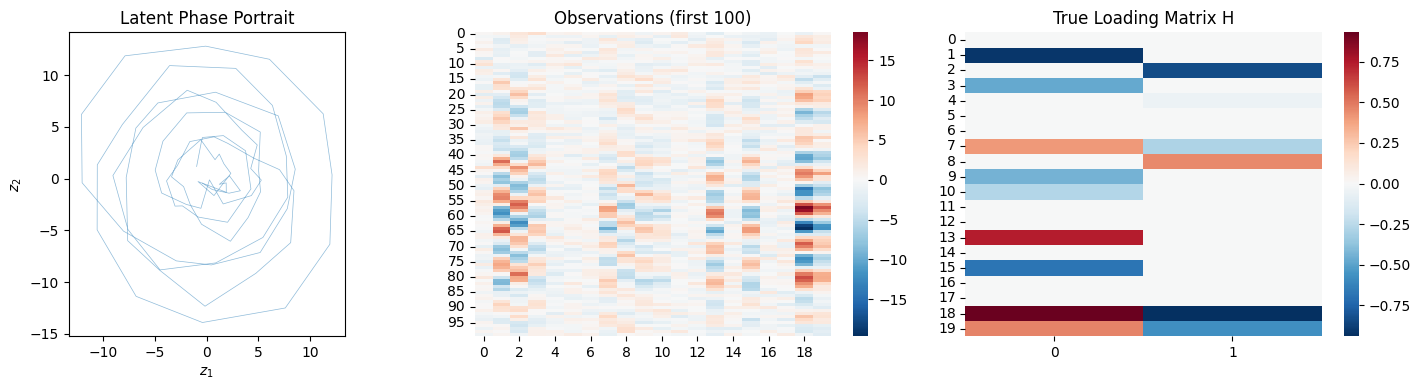

In [3]:
# Data dimensions
T = 100   # time steps
D = 20    # features
K = 2     # latent components

key = jr.PRNGKey(42)

# True dynamics: damped 2D rotation
theta = jnp.pi / 6
rho = 0.95
F_true = rho * jnp.array([[jnp.cos(theta), -jnp.sin(theta)],
                           [jnp.sin(theta),  jnp.cos(theta)]])
Q_true = jnp.eye(K)

# True sparse loading matrix
key, k1, k2 = jr.split(key, 3)
H_true = jr.normal(k1, (D, K)) * jr.bernoulli(k2, p=0.3, shape=(D, K))

# True diagonal noise covariance
key, k1 = jr.split(key)
R_true_diag = jr.uniform(k1, (D,), minval=0.95, maxval=1.05)
R_true = jnp.diag(R_true_diag)

# Initial state
mu0_true = jnp.zeros(K)
Sigma0_true = jnp.eye(K)

# Generate latent states and observations
z_true = jnp.zeros((T, K))
y_obs = jnp.zeros((T, D))

key, k1, k2 = jr.split(key, 3)
z_curr = jr.multivariate_normal(k1, mu0_true, Sigma0_true)
z_true = z_true.at[0].set(z_curr)
y_obs = y_obs.at[0].set(jr.multivariate_normal(k2, H_true @ z_curr, R_true))

for t in range(1, T):
    key, k1, k2 = jr.split(key, 3)
    z_curr = jr.multivariate_normal(k1, F_true @ z_curr, Q_true)
    z_true = z_true.at[t].set(z_curr)
    y_obs = y_obs.at[t].set(jr.multivariate_normal(k2, H_true @ z_curr, R_true))

print(f"y_obs shape: {y_obs.shape}, H_true shape: {H_true.shape}")
print(f"F_true eigenvalues: {jnp.linalg.eigvals(F_true)}")
print(f"H_true sparsity: {jnp.isclose(H_true, 0.).mean():.1%} zeros")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(z_true[:, 0], z_true[:, 1], alpha=0.5, lw=0.5)
axes[0].set_xlabel('$z_1$'); axes[0].set_ylabel('$z_2$')
axes[0].set_title('Latent Phase Portrait')
axes[0].set_aspect('equal')
sns.heatmap(y_obs[:100], ax=axes[1], cmap='RdBu_r', center=0)
axes[1].set_title('Observations (first 100)')
sns.heatmap(H_true, ax=axes[2], cmap='RdBu_r', center=0)
axes[2].set_title('True Loading Matrix H')
plt.tight_layout()

## 2. PXL-EM Correction for DFA

In [4]:
def dfa_pxl_em_correction(params, stats, state_dim):
    """PXL-EM correction for DFA: rotate emissions, dynamics, and initial distribution.
    
    After the standard M-step produces B* (loading in expanded space),
    compute A = (1/T) sum E[z_t z_t^T], A_L = chol(A), and apply:
        H_new = H @ A_L
        F_new = A_L^{-1} @ F @ A_L
        B_new = A_L^{-1} @ B, b_new = A_L^{-1} @ b
        mu_new = A_L^{-1} @ mu, Sigma_new = A_L^{-1} @ Sigma @ A_L^{-T}
    Q = I is kept fixed.
    """
    K = state_dim
    T_total = stats[3]
    sum_zzT = stats[0]
    
    A = sum_zzT[:K, :K] / T_total
    A_L = jnp.linalg.cholesky(A)
    A_L_inv = jnp.linalg.inv(A_L)

    # Emissions: H_new = H @ A_L
    H_new = params.emissions.weights @ A_L

    # Dynamics: F_new = A_L^{-1} F A_L, B_new = A_L^{-1} B, b_new = A_L^{-1} b
    F_new = A_L_inv @ params.dynamics.weights @ A_L
    B_new = A_L_inv @ params.dynamics.input_weights
    b_new = A_L_inv @ params.dynamics.bias

    # Initial: mu_new = A_L^{-1} mu, Sigma_new = A_L^{-1} Sigma A_L^{-T}
    mu_new = A_L_inv @ params.initial.mean
    Sigma_new = A_L_inv @ params.initial.cov @ A_L_inv.T

    params = params._replace(
        initial=params.initial._replace(mean=mu_new, cov=Sigma_new),
        dynamics=params.dynamics._replace(
            weights=F_new, input_weights=B_new, bias=b_new),
        emissions=params.emissions._replace(weights=H_new),
    )
    return params, A_L

## 3. EM Loop Functions

In [5]:
def fit_pxl_em_dfa(model, params, props, y, key, num_iters=40):
    """PXL-EM for DFA: standard EM + PXL rotation correction after each M-step."""
    batch_emissions = y[None]  # (1, T, D)

    m_step_state = model.initialize_m_step_state(params, props)
    kl_div = 0.0
    elbos = []

    for i in range(num_iters):
        key, _key = jr.split(key)
        # E-step
        batch_stats, lls = vmap(partial(model.e_step, params))(batch_emissions, None)
        elbo = lls.sum() - kl_div
        elbos.append(float(elbo))

        # M-step
        params, kl_div, m_step_state = model.m_step(
            params, props, batch_stats, m_step_state, key=_key)

        # PXL-EM correction
        stats = jtu.tree_map(partial(jnp.sum, axis=0), batch_stats)
        _, _, emission_stats = stats
        params, A_L = dfa_pxl_em_correction(params, emission_stats, model.state_dim)

    model.ard_prior = m_step_state
    return params, jnp.array(elbos)

## 4. VBEM Loop Functions

In [6]:
def fit_pxl_vbem_dfa(model, params, props, y, key, num_iters=40):
    """PXL-VBEM for DFA: VBEM + PXL rotation correction.
    
    Also transforms VB correction terms:
        C_em_new = A_L_full^T @ C_em @ A_L_full
        C_dyn_new = A_L_full^T @ C_dyn @ A_L_full
    """
    batch_emissions = y[None]  # (1, T, D)

    m_step_state = model.initialize_m_step_state(params, props)
    kl_div = 0.0
    elbos = []

    for i in range(num_iters):
        key, _key = jr.split(key)
        # VB E-step
        batch_stats, lls = vmap(partial(model.vbe_step, params))(batch_emissions, None)
        elbo = lls.sum() - kl_div
        elbos.append(float(elbo))

        # VB M-step
        params, kl_div, m_step_state = model.vbm_step(
            params, props, batch_stats, m_step_state, key=_key)

        # PXL-EM correction
        stats = jtu.tree_map(partial(jnp.sum, axis=0), batch_stats)
        _, dynamics_stats, _ = stats

        K = model.state_dim
        T_total = dynamics_stats[3]
        sum_zpzpT = dynamics_stats[0]
        sum_zpzmT = dynamics_stats[1]
        sum_zmzmT = dynamics_stats[2]
        F = params.dynamics.weights
        C = params.dynamics.correction
        FTF = F @ sum_zmzmT @ F.T + jnp.diag(jnp.trace(C[:K, :K] @ sum_zmzmT, axis1=-1, axis2=-2)) 
        corr = sum_zpzmT @ F.T

        A = (sum_zpzpT[:K, :K] - corr - corr.T + FTF) / T_total
        A_L = jnp.linalg.cholesky(A)
        A_L_inv = jnp.linalg.inv(A_L)

        # Rotate emissions
        H_new = params.emissions.weights @ A_L

        # Transform C_em: A_L_full^T @ C_em @ A_L_full
        C_em = params.emissions.correction
        A_L_em_full = jnp.eye(C_em.shape[-1])
        A_L_em_full = A_L_em_full.at[:K, :K].set(A_L)
        C_em_new = A_L_em_full.T @ C_em @ A_L_em_full

        # Rotate dynamics
        F_new = A_L_inv @ params.dynamics.weights @ A_L
        B_new = A_L_inv @ params.dynamics.input_weights
        b_new = A_L_inv @ params.dynamics.bias

        # Transform C_dyn: A_L_full^T @ C_dyn @ A_L_full
        C_dyn = params.dynamics.correction
        A_L_dyn_full = jnp.eye(C_dyn.shape[-1])
        A_L_dyn_full = A_L_dyn_full.at[:K, :K].set(A_L)
        C_dyn_new = A_L_dyn_full.T @ C_dyn @ A_L_dyn_full

        # Rotate initial
        mu_new = A_L_inv @ params.initial.mean
        Sigma_new = A_L_inv @ params.initial.cov @ A_L_inv.T

        params = params._replace(
            initial=params.initial._replace(mean=mu_new, cov=Sigma_new),
            dynamics=params.dynamics._replace(
                weights=F_new, input_weights=B_new, bias=b_new,
                correction=C_dyn_new),
            emissions=params.emissions._replace(
                weights=H_new, correction=C_em_new),
        )

    model.ard_prior = m_step_state
    return params, jnp.array(elbos)

## 5. Experiments Without BMR

In [7]:
NUM_ITERS = 40

emission_prior = MVNIG(
    loc=jnp.zeros((D, 2 * K + 1)),
    isotropic_noise=False
)

loc = jnp.eye(2 * K)
dynamics_prior = MultivariateNormal(loc=loc)

# --- Standard EM ---
model = BDFA(2 * K, D, 
    emission_prior=emission_prior,
    dynamics_prior=dynamics_prior,
    has_dynamics_bias=False,
    has_ard=False, use_bmr=False
)
key, k1, k2 = jr.split(key, 3)
params_init, props = model.initialize(k1)
params_em, elbos_em = model.fit_em(params_init, props, y_obs, k2, num_iters=NUM_ITERS)
print(f"EM final ELBO: {elbos_em[-1]:.1f}")

# --- PXL-EM ---
key, k1, k2 = jr.split(key, 3)
params_pxl, elbos_pxl = fit_pxl_em_dfa(model, params_init, props, y_obs, k2, num_iters=NUM_ITERS)
print(f"PXL-EM final ELBO: {elbos_pxl[-1]:.1f}")

# --- Standard VBEM ---
key, k1, k2 = jr.split(key, 3)
params_vbem_init, props_vbem = model.initialize(k1, variational_bayes=True)
params_vbem, elbos_vbem = model.fit_vbem(params_vbem_init, props_vbem, y_obs, k2, num_iters=NUM_ITERS)
print(f"VBEM final ELBO: {elbos_vbem[-1]:.1f}")

# --- PXL-VBEM ---
key, k1, k2 = jr.split(key, 3)
params_pxl_vb, elbos_pxl_vb = fit_pxl_vbem_dfa(model, params_vbem_init, props_vbem, y_obs, k2, num_iters=NUM_ITERS)
print(f"PXL-VBEM final ELBO: {elbos_pxl_vb[-1]:.1f}")

EM final ELBO: -3685.1
PXL-EM final ELBO: -3746.3
VBEM final ELBO: -3303.9
PXL-VBEM final ELBO: -3447.9


### Convergence Comparison (No BMR)

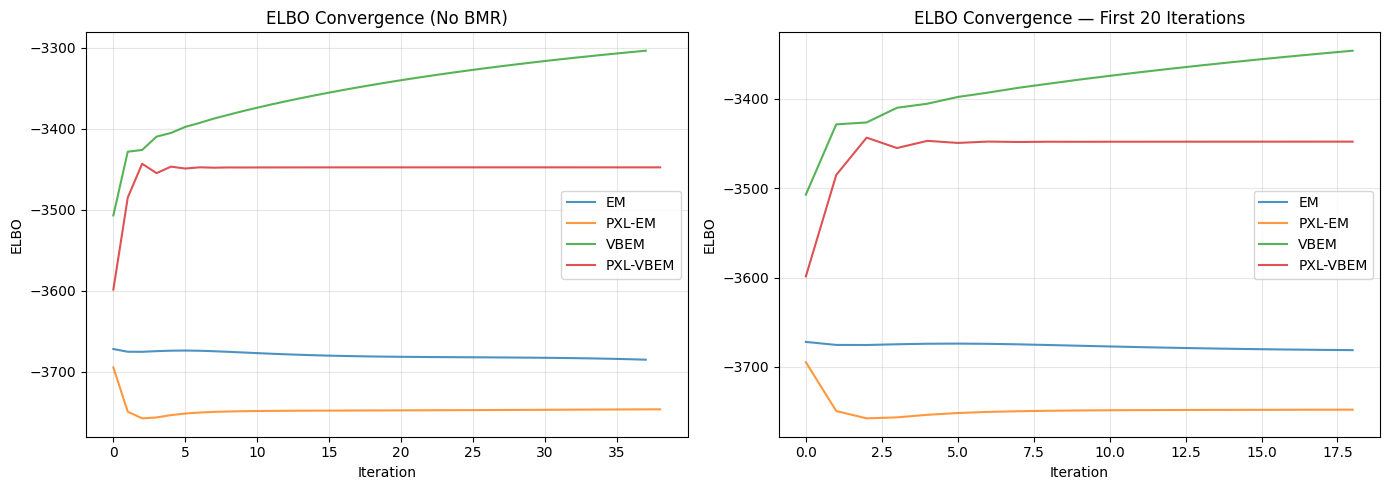

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(elbos_em[1:], label='EM', alpha=0.8)
ax.plot(elbos_pxl[1:], label='PXL-EM', alpha=0.8)
ax.plot(elbos_vbem[1:], label='VBEM', alpha=0.8)
ax.plot(elbos_pxl_vb[1:], label='PXL-VBEM', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('ELBO Convergence (No BMR)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(elbos_em[1:20], label='EM', alpha=0.8)
ax.plot(elbos_pxl[1:20], label='PXL-EM', alpha=0.8)
ax.plot(elbos_vbem[1:20], label='VBEM', alpha=0.8)
ax.plot(elbos_pxl_vb[1:20], label='PXL-VBEM', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('ELBO Convergence \u2014 First 20 Iterations')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

### Loading Matrix & Latent State Recovery (No BMR)

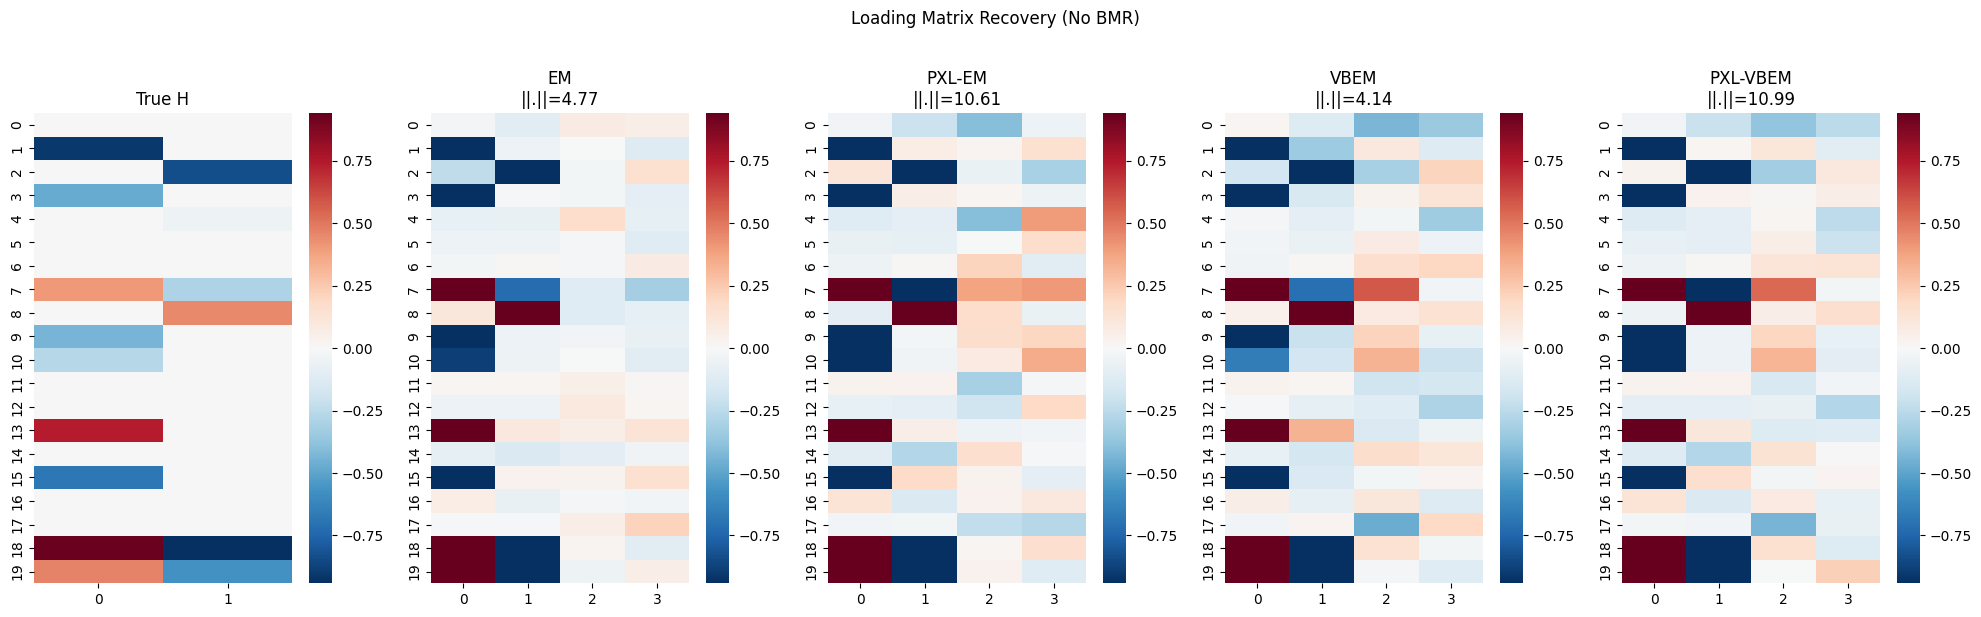

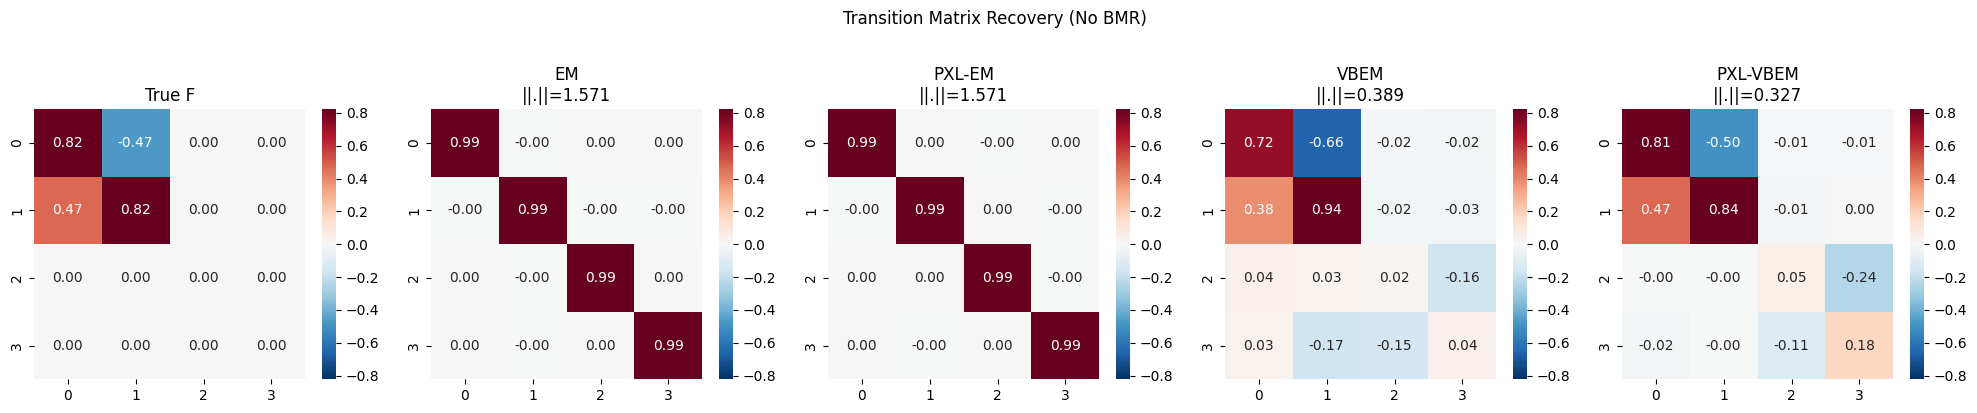

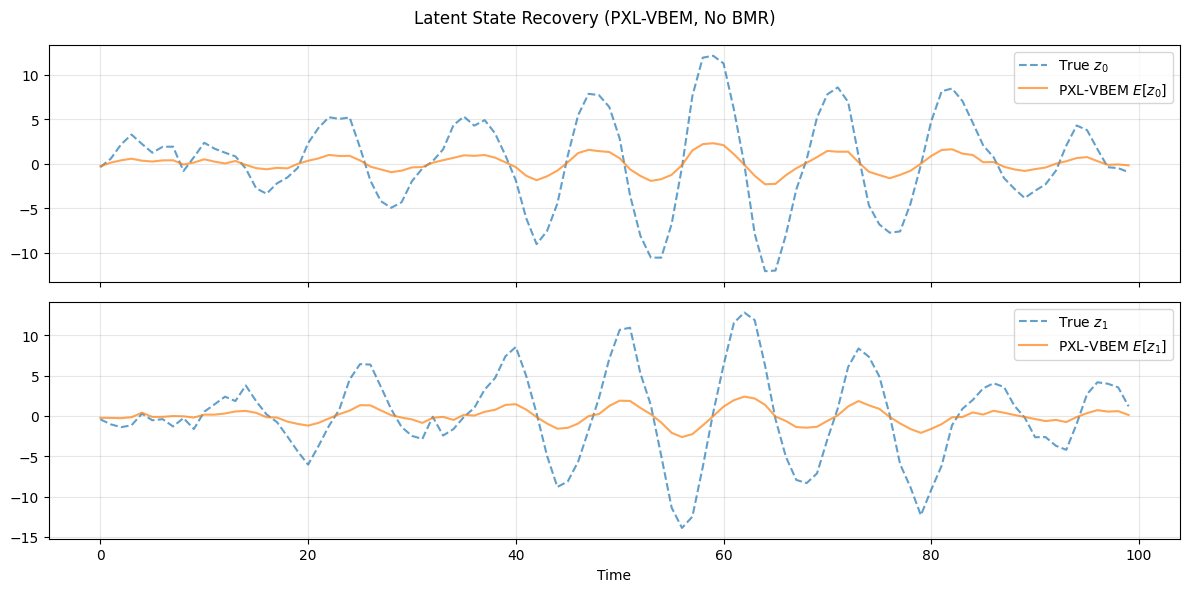

In [9]:
def procrustes_similarity(H_est, H_true):
    """Align H_est to H_true via orthogonal Procrustes.
    
    Handles different number of columns by zero-padding.
    Returns aligned H_est and Frobenius disparity.
    """
    D, K_est = H_est.shape
    K_true = H_true.shape[1]
    K_max = max(K_est, K_true)

    A = jnp.pad(H_est, [(0, 0), (0, K_max - K_est)]) if K_est < K_max else H_est
    B = jnp.pad(H_true, [(0, 0), (0, K_max - K_true)]) if K_true < K_max else H_true

    R, _ = orthogonal_procrustes(A, B)
    H_aligned = A @ R
    disparity = jnp.linalg.norm(H_aligned - B, 'fro')
    return H_aligned, float(disparity), R


results_no_bmr = {
    'EM': params_em,
    'PXL-EM': params_pxl,
    'VBEM': params_vbem,
    'PXL-VBEM': params_pxl_vb,
}

# Loading recovery
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
vmax = jnp.abs(H_true).max()

sns.heatmap(H_true, ax=axes[0], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
axes[0].set_title('True H')

Ezs = {}
procrustes_Rs = {}
for idx, (name, p) in enumerate(results_no_bmr.items()):
    H_aligned, disparity, R = procrustes_similarity(p.emissions.weights, H_true)
    procrustes_Rs[name] = R
    sns.heatmap(H_aligned, ax=axes[idx + 1], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
    axes[idx + 1].set_title(f'{name}\n||.||={disparity:.2f}')

    post = parallel_lgssm_smoother(p, y_obs)
    Ezs[name] = solve(R, post.smoothed_means[..., None])[..., 0]

plt.suptitle('Loading Matrix Recovery (No BMR)', y=1.02)
plt.tight_layout()

# Transition matrix recovery: F_aligned = R^T @ F_est @ R
K_true = H_true.shape[1]
K_est = params_em.emissions.weights.shape[1]
K_max = max(K_est, K_true)
F_true_pad = jnp.pad(F_true, [(0, K_max - K_true), (0, K_max - K_true)])

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
vmax_f = max(jnp.abs(F_true).max(), 0.5)

sns.heatmap(F_true_pad, ax=axes[0], cmap='RdBu_r', center=0, vmin=-vmax_f, vmax=vmax_f, annot=True, fmt='.2f')
axes[0].set_title('True F')

for idx, (name, p) in enumerate(results_no_bmr.items()):
    R = procrustes_Rs[name]
    F_aligned = R.T @ p.dynamics.weights @ R
    err = jnp.linalg.norm(F_aligned - F_true_pad, 'fro')
    sns.heatmap(F_aligned, ax=axes[idx + 1], cmap='RdBu_r', center=0, vmin=-vmax_f, vmax=vmax_f, annot=True, fmt='.2f')
    axes[idx + 1].set_title(f'{name}\n||.||={err:.3f}')

plt.suptitle('Transition Matrix Recovery (No BMR)', y=1.02)
plt.tight_layout()

# Latent state recovery
fig, axes = plt.subplots(K, 1, figsize=(12, 3 * K), sharex=True)
name = 'PXL-VBEM'
for i in range(K):
    axes[i].plot(z_true[:, i], label=f'True $z_{i}$', ls='--', alpha=0.7)
    axes[i].plot(Ezs[name][:, i], label=f'{name} $E[z_{i}]$', alpha=0.7)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('Time')
plt.suptitle(f'Latent State Recovery ({name}, No BMR)')
plt.tight_layout()

## 6. Experiments With BMR

In [14]:
NUM_ITERS_BMR = 40

# --- Standard EM + BMR ---
model_bmr = BDFA(
    2 * K,
    D, 
    emission_prior=emission_prior, 
    dynamics_prior=dynamics_prior,
    has_dynamics_bias=False,
    has_ard=True, use_bmr=True
)
key, k1, k2 = jr.split(key, 3)
params_init_bmr, props_bmr = model_bmr.initialize(k1)
params_em_bmr, elbos_em_bmr = model_bmr.fit_em(
    params_init_bmr, props_bmr, y_obs, k2, num_iters=NUM_ITERS_BMR)
print(f"EM+BMR final ELBO: {elbos_em_bmr[-1]:.1f}")

# --- PXL-EM + BMR ---
model_bmr2 = BDFA(
    2 * K, D,
    emission_prior=emission_prior,
    dynamics_prior=dynamics_prior,
    has_dynamics_bias=False,
    has_ard=True, use_bmr=True
)
key, k2 = jr.split(key)
params_pxl_bmr, elbos_pxl_bmr = fit_pxl_em_dfa(
    model_bmr2, params_init_bmr, props_bmr, y_obs, k2, num_iters=NUM_ITERS_BMR)
print(f"PXL-EM+BMR final ELBO: {elbos_pxl_bmr[-1]:.1f}")

EM+BMR final ELBO: nan
PXL-EM+BMR final ELBO: nan


In [15]:
# --- Standard VBEM + BMR ---
model_bmr3 = BDFA(
    2 * K,
    D, 
    emission_prior=emission_prior, 
    dynamics_prior=dynamics_prior,
    has_dynamics_bias=False,
    has_ard=True, use_bmr=True
)
key, k1, k2 = jr.split(key, 3)
params_vbem_bmr_init, props_vbem_bmr = model_bmr3.initialize(k1, variational_bayes=True)
params_vbem_bmr, elbos_vbem_bmr = model_bmr3.fit_vbem(
    params_vbem_bmr_init, props_vbem_bmr, y_obs, k2, num_iters=NUM_ITERS_BMR)
print(f"VBEM+BMR final ELBO: {elbos_vbem_bmr[-1]:.1f}")

# --- PXL-VBEM + BMR ---
model_bmr4 = BDFA(
    2 * K,
    D, 
    emission_prior=emission_prior, 
    dynamics_prior=dynamics_prior,
    has_dynamics_bias=False,
    has_ard=True, use_bmr=True
)
key, k2 = jr.split(key)
params_pxl_vb_bmr, elbos_pxl_vb_bmr = fit_pxl_vbem_dfa(
    model_bmr4, params_vbem_bmr_init, props_vbem_bmr, y_obs, k2, num_iters=NUM_ITERS_BMR)
print(f"PXL-VBEM+BMR final ELBO: {elbos_pxl_vb_bmr[-1]:.1f}")

VBEM+BMR final ELBO: -3536.6
PXL-VBEM+BMR final ELBO: -6712.9


### Convergence Comparison (With BMR)

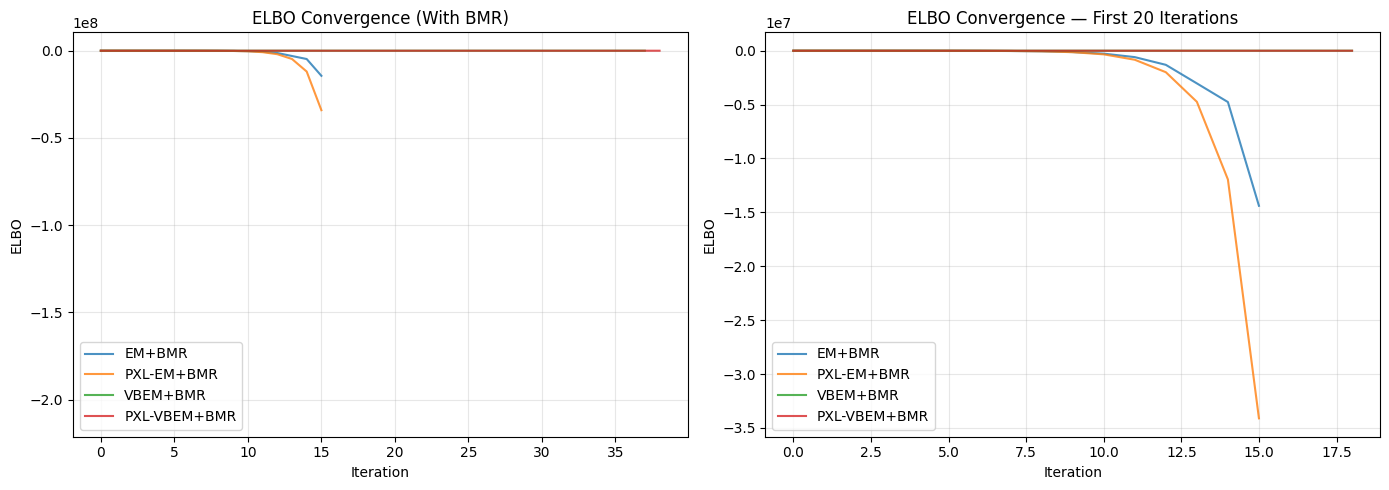

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(elbos_em_bmr[1:], label='EM+BMR', alpha=0.8)
ax.plot(elbos_pxl_bmr[1:], label='PXL-EM+BMR', alpha=0.8)
ax.plot(elbos_vbem_bmr[1:], label='VBEM+BMR', alpha=0.8)
ax.plot(elbos_pxl_vb_bmr[1:], label='PXL-VBEM+BMR', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('ELBO Convergence (With BMR)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(elbos_em_bmr[1:20], label='EM+BMR', alpha=0.8)
ax.plot(elbos_pxl_bmr[1:20], label='PXL-EM+BMR', alpha=0.8)
ax.plot(elbos_vbem_bmr[1:20], label='VBEM+BMR', alpha=0.8)
ax.plot(elbos_pxl_vb_bmr[1:20], label='PXL-VBEM+BMR', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('ELBO Convergence \u2014 First 20 Iterations')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

### Loading Matrix Recovery (With BMR)

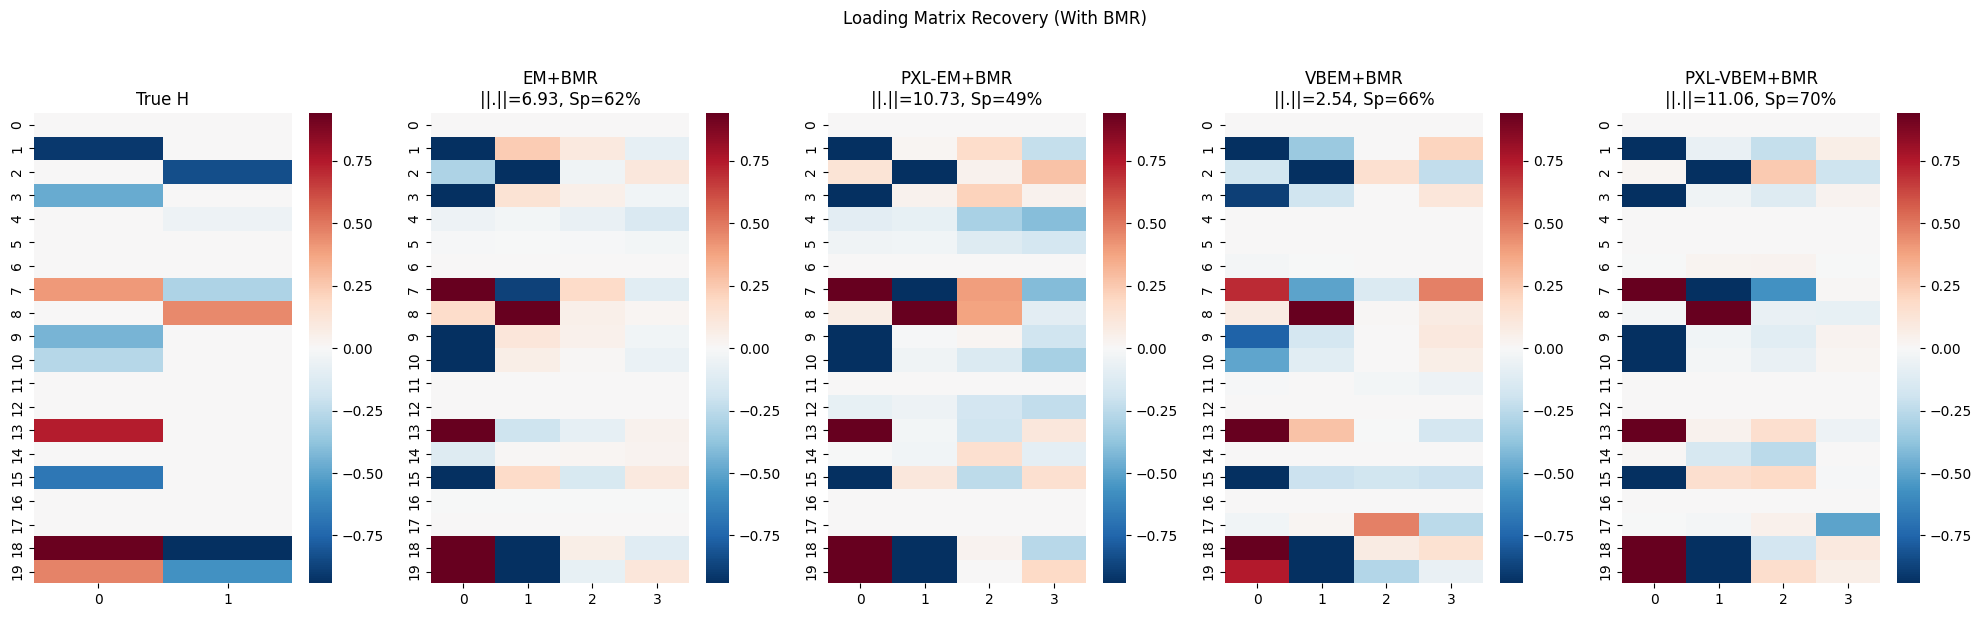

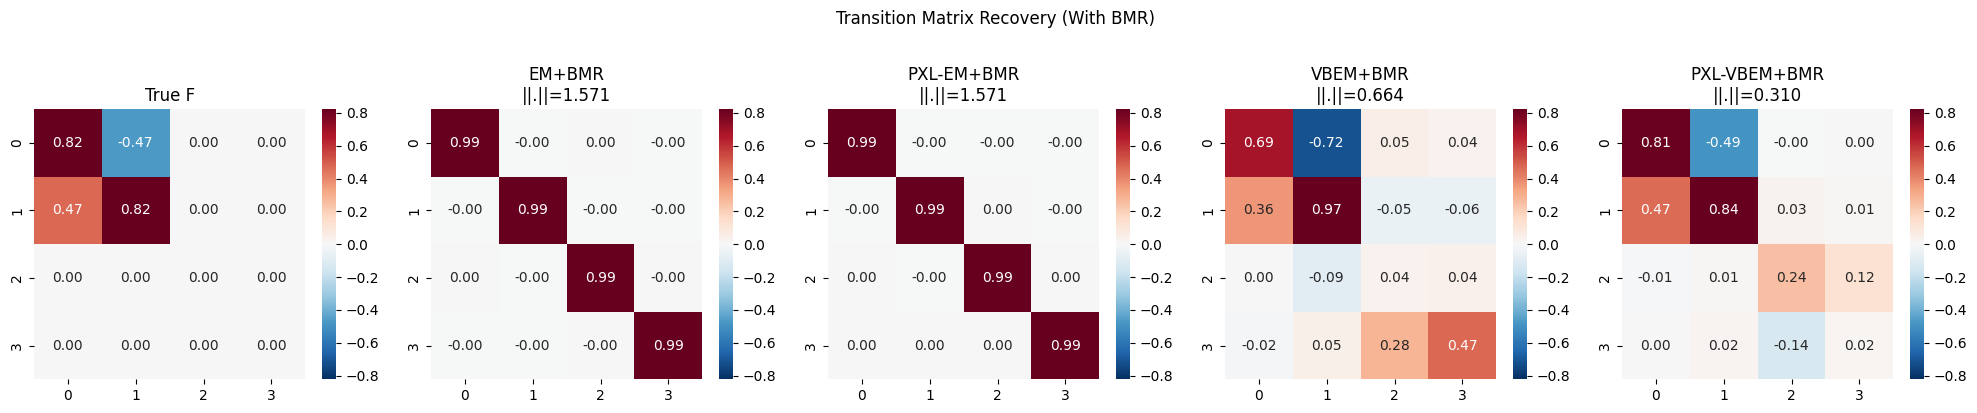

In [17]:
results_bmr = {
    'EM+BMR': params_em_bmr,
    'PXL-EM+BMR': params_pxl_bmr,
    'VBEM+BMR': params_vbem_bmr,
    'PXL-VBEM+BMR': params_pxl_vb_bmr,
}

# Loading recovery
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
vmax = jnp.abs(H_true).max()

sns.heatmap(H_true, ax=axes[0], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
axes[0].set_title('True H')

procrustes_Rs_bmr = {}
for idx, (name, p) in enumerate(results_bmr.items()):
    H_aligned, disparity, R = procrustes_similarity(p.emissions.weights, H_true)
    procrustes_Rs_bmr[name] = R
    sparsity = jnp.mean(jnp.abs(p.emissions.weights) < 0.05)
    sns.heatmap(H_aligned, ax=axes[idx + 1], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
    axes[idx + 1].set_title(f'{name}\n||.||={disparity:.2f}, Sp={sparsity:.0%}')

plt.suptitle('Loading Matrix Recovery (With BMR)', y=1.02)
plt.tight_layout()

# Transition matrix recovery
K_bmr = params_em_bmr.dynamics.weights.shape[0]
F_true_bmr = F_true[:K_bmr, :K_bmr] if K_bmr <= K_true else jnp.pad(F_true, [(0, K_bmr - K_true)] * 2)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
vmax_f = max(jnp.abs(F_true).max(), 0.5)

sns.heatmap(F_true_bmr, ax=axes[0], cmap='RdBu_r', center=0, vmin=-vmax_f, vmax=vmax_f, annot=True, fmt='.2f')
axes[0].set_title('True F')

for idx, (name, p) in enumerate(results_bmr.items()):
    R = procrustes_Rs_bmr[name]
    F_aligned = R.T @ p.dynamics.weights @ R
    err = jnp.linalg.norm(F_aligned - F_true_bmr, 'fro')
    sns.heatmap(F_aligned, ax=axes[idx + 1], cmap='RdBu_r', center=0, vmin=-vmax_f, vmax=vmax_f, annot=True, fmt='.2f')
    axes[idx + 1].set_title(f'{name}\n||.||={err:.3f}')

plt.suptitle('Transition Matrix Recovery (With BMR)', y=1.02)
plt.tight_layout()

## 7. Summary

**DFA PXL-EM correction:**
After each M-step, compute $\mathbf{A} = \frac{1}{T} \sum_t \mathbb{E}[\mathbf{z}_t \mathbf{z}_t^\top]$
and $\mathbf{A}_L = \text{chol}(\mathbf{A})$, then:
- $\mathbf{H}_{\text{new}} = \mathbf{H} \mathbf{A}_L$
- $\mathbf{F}_{\text{new}} = \mathbf{A}_L^{-1} \mathbf{F} \mathbf{A}_L$
- $\boldsymbol{\mu}_{0,\text{new}} = \mathbf{A}_L^{-1} \boldsymbol{\mu}_0$,
  $\boldsymbol{\Sigma}_{0,\text{new}} = \mathbf{A}_L^{-1} \boldsymbol{\Sigma}_0 \mathbf{A}_L^{-\top}$
- $\mathbf{Q} = \mathbf{I}$ (kept fixed)
- For VBEM: $\mathbf{C}_{\text{new}} = \mathbf{A}_{L,\text{full}}^\top \mathbf{C} \mathbf{A}_{L,\text{full}}$

**Expected findings:**
- PXL-EM converges faster than standard EM
- The 2D rotation dynamics test whether PXL-EM can correctly handle coupled latent dynamics
- BMR enables sparse loading recovery